# LSTM: Trajektorie lernen → danach Wurf klassifizieren (clean, noisy, trimmed)

Zielsetzung:
- Das LSTM lernt die Trajektorie \((x(t), y(t))\).
- Nach dem Training wird jede vorhergesagte Trajektorie klassifiziert:
  `0=zu kurz`, `1=Treffer`, `2=zu lang`.
- Auswertung: Loss-Kurven, Beispieltrajektorien (Ground Truth vs. Vorhersage), Konfusionsmatrix & Metriken.

**Labels (DataGen):** 0 = short/low, 1 = hit, 2 = long/high.


In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
class DataGen:
    """
    Synthetic Free-Throw Generator (ballistic, no drag).
    """

    def __init__(self, hs=2.13, l=4.115, hKorb=3.048, Rr=0.2286, Rb=0.1219, g=9.807):
        self.params = {
            "l": float(l),
            "hKorb": float(hKorb),
            "Rr": float(Rr),
            "Rb": float(Rb),
            "g": float(g),
        }
        self.hs = float(hs)
        self.wurf_hoehe = 1.25 * self.hs  # release height

    def wurfgeschwindigkeit(self, theta):
        l = self.params["l"]
        h = self.params["hKorb"] - self.wurf_hoehe
        g = self.params["g"]
        return (l / np.cos(theta)) * np.sqrt(g / (2 * (l * np.tan(theta) - h)))

    def wurftrajektorien(self, theta, v0, t):
        g = self.params["g"]
        vx = v0 * np.cos(theta)
        vy = v0 * np.sin(theta)
        x = vx * t
        y = vy * t - 0.5 * g * t**2 + self.wurf_hoehe
        return x, y, vx, vy

    def _t_at_height_desc(self, theta, v0, y_target):
        """
        Returns the *descending* time t>0 when y(t) = y_target.
        If not reachable -> returns None.
        """
        g = self.params["g"]
        y0 = self.wurf_hoehe

        vx = v0 * np.cos(theta)
        vy = v0 * np.sin(theta)
        if vx <= 0:
            return None

        # Solve: y0 + vy*t - 0.5*g*t^2 = y_target
        # => 0.5*g*t^2 - vy*t + (y_target - y0) = 0
        a = 0.5 * g
        b = -vy
        c = y_target - y0

        disc = b * b - 4 * a * c
        if disc <= 0:
            return None

        sqrt_disc = np.sqrt(disc)
        t1 = (-b - sqrt_disc) / (2 * a)
        t2 = (-b + sqrt_disc) / (2 * a)

        t_desc = max(t1, t2)  # descending root (for y_target > y0 typically)
        if t_desc <= 0:
            return None
        return float(t_desc)

    def label_from_trajectory(self, theta, v0, margin=0.0):
        """
        Labels:
          0: short/low (zu kurz oder Korbhöhe wird nie erreicht)
          1: hit (bei y=hKorb liegt x nahe l innerhalb (Rr-Rb))
          2: long/high (zu weit)
        """
        l = self.params["l"]
        h = self.params["hKorb"]
        Rr = self.params["Rr"]
        Rb = self.params["Rb"]

        vx = v0 * np.cos(theta)

        r_clear = max(0.0, (Rr - Rb) + margin)

        t_desc = self._t_at_height_desc(theta, v0, h)
        if t_desc is None or vx <= 0:
            return 0

        x_at_hoop_height = vx * t_desc

        if abs(x_at_hoop_height - l) <= r_clear:
            return 1
        elif x_at_hoop_height < l - r_clear:
            return 0
        else:
            return 2

    def generate_dataset(
        self,
        base_theta_deg=48.43,
        n=150,
        n_points=50,
        with_noise=False,
        noise_std=0.01,
        dtheta_range=(-0.20, 0.20),
        dv0_range=(-0.8, 0.8),
        margin=0.0,
        max_resample=1000,
        force_exact_endpoint=True,
    ):
        """
        Generates trajectories that END at hoop height:
        - last sample has y == hKorb (and x ~ vx*T, typically near l depending on theta/v0)

        Returns dataframe with columns:
        wurf_id, t, x_clean, y_clean, x_noisy, y_noisy, x, y, T, label, theta, v0
        """
        base_theta = np.deg2rad(base_theta_deg)
        base_v0 = self.wurfgeschwindigkeit(base_theta)

        h = self.params["hKorb"]

        rows = []
        for wid in range(n):
            # resample until the shot reaches hoop height (y=hKorb)
            theta = None
            v0 = None
            T = None
            for _ in range(max_resample):
                dth = np.random.uniform(*dtheta_range)
                dv0 = np.random.uniform(*dv0_range)
                theta_try = base_theta + dth
                v0_try = base_v0 + dv0

                t_desc = self._t_at_height_desc(theta_try, v0_try, h)
                if t_desc is not None:
                    theta, v0, T = theta_try, v0_try, t_desc
                    break

            if T is None:
                raise RuntimeError(
                    f"Could not sample a valid throw reaching hoop height after {max_resample} tries."
                )

            label = self.label_from_trajectory(theta, v0, margin=margin)

            t_vals = np.linspace(0.0, T, n_points, dtype=np.float32)
            x, y, vx, vy = self.wurftrajektorien(theta, v0, t_vals)

            x_clean = x.copy()
            y_clean = y.copy()

            if force_exact_endpoint:
                vx0 = v0 * np.cos(theta)
                x_clean[-1] = float(vx0 * T)
                y_clean[-1] = float(h)

            if with_noise:
                x_noisy = x_clean + np.random.normal(0.0, noise_std, size=x_clean.shape)
                y_noisy = y_clean + np.random.normal(0.0, noise_std, size=y_clean.shape)

                # keep endpoint exactly on hoop height if desired
                if force_exact_endpoint:
                    x_noisy[-1] = x_clean[-1]
                    y_noisy[-1] = y_clean[-1]
            else:
                x_noisy = x_clean.copy()
                y_noisy = y_clean.copy()

            x_sel = x_noisy if with_noise else x_clean
            y_sel = y_noisy if with_noise else y_clean

            for ti, xc, yc, xn, yn, xi, yi in zip(
                t_vals, x_clean, y_clean, x_noisy, y_noisy, x_sel, y_sel
            ):
                rows.append(
                    {
                        "wurf_id": wid,
                        "t": float(ti),
                        "x_clean": float(xc),
                        "y_clean": float(yc),
                        "x_noisy": float(xn),
                        "y_noisy": float(yn),
                        "x": float(xi),
                        "y": float(yi),
                        "T": float(T),
                        "label": int(label),
                        "theta": float(theta),
                        "v0": float(v0),
                    }
                )

        return pd.DataFrame(rows)

In [3]:
def add_point_index_and_tnorm(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    # point_index (1..50) pro Wurf – nach t sortiert
    d = d.sort_values(["wurf_id", "t"]).copy()
    d["point_index"] = d.groupby("wurf_id").cumcount() + 1

    # t_norm pro Wurf in [0,1]
    tmax = d.groupby("wurf_id")["t"].transform("max").replace(0, 1e-8)
    d["t_norm"] = (d["t"] / tmax).astype(np.float32)
    return d


def split_by_wurf_id(df: pd.DataFrame, test_size=0.2, seed=42):
    wids = df["wurf_id"].unique()
    tr, va = train_test_split(
        wids, test_size=test_size, random_state=seed, shuffle=True
    )
    return df[df["wurf_id"].isin(tr)].copy(), df[df["wurf_id"].isin(va)].copy()


class XYScaler:
    """Simple StandardScaler nur für x,y (fit nur auf Train!)."""

    def fit(self, xy: np.ndarray):
        self.mean_ = xy.mean(axis=0)
        self.std_ = xy.std(axis=0)
        self.std_[self.std_ == 0] = 1.0
        return self

    def transform(self, xy: np.ndarray):
        return (xy - self.mean_) / self.std_

    def inverse_transform(self, xy: np.ndarray):
        return xy * self.std_ + self.mean_

In [4]:
class TrajectoryCompletionDataset(Dataset):
    """
    Unified dataset for three modes:

      1) clean:   clean50  -> clean50
      2) noisy:   noisy50  -> noisy50          (explicitly kept as requested)
      3) trimmed: (clean/noisy)30 -> clean50   (sequence completion / extrapolation)

    Output shapes:
      X: (T, 4) = [x_in_scaled, y_in_scaled, t_norm, known_mask]
      Y: (T, 2) = [x_target_scaled, y_target_scaled]
      C: int label

    Notes:
      - For 'trimmed', the input is padded to length T with zeros (in scaled space)
        for unknown timesteps, and known_mask indicates which timesteps are observed.
      - The scaler is ALWAYS fitted on the TARGET distribution (train set only).
        That means:
          * clean   -> fit on clean targets
          * noisy   -> fit on noisy targets
          * trimmed -> fit on clean targets
    """

    def __init__(
        self,
        df: pd.DataFrame,
        mode: str = "clean",                 # "clean" | "noisy" | "trimmed"
        seq_len: int = 50,
        input_len: int = 30,                 # only used for trimmed
        input_variant: str = "noisy",         # "clean" | "noisy" (only for trimmed)
        scaler=None,
        fit_scaler: bool = False,
    ):
        assert mode in ("clean", "noisy", "trimmed")
        assert input_variant in ("clean", "noisy")

        self.mode = mode
        self.seq_len = int(seq_len)
        self.input_len = int(input_len)
        self.input_variant = input_variant

        self.df = add_point_index_and_tnorm(df)
        self.scaler = scaler if scaler is not None else XYScaler()

        # pre-collect throws (exactly seq_len points)
        self.throws = []
        for _, g in self.df.groupby("wurf_id"):
            g = g.sort_values("point_index")
            if len(g) >= self.seq_len:
                self.throws.append(g.iloc[: self.seq_len].copy())

        # choose columns
        self._clean_cols = ["x_clean", "y_clean"]
        self._noisy_cols = ["x_noisy", "y_noisy"]

        def target_cols():
            if self.mode == "noisy":
                return self._noisy_cols
            # clean + trimmed target is clean
            return self._clean_cols

        self._target_cols = target_cols()

        if fit_scaler:
            xy = np.concatenate(
                [g[self._target_cols].values.astype(np.float32) for g in self.throws],
                axis=0,
            )
            self.scaler.fit(xy)

    def __len__(self):
        return len(self.throws)

    def __getitem__(self, idx):
        g = self.throws[idx]

        # target trajectory (always full length)
        xy_tgt = g[self._target_cols].values.astype(np.float32)
        xy_tgt_s = self.scaler.transform(xy_tgt).astype(np.float32)

        # input trajectory columns
        if self.mode == "clean":
            in_cols = self._clean_cols
            known = np.ones((self.seq_len, 1), dtype=np.float32)
        elif self.mode == "noisy":
            in_cols = self._noisy_cols
            known = np.ones((self.seq_len, 1), dtype=np.float32)
        else:  # trimmed
            in_cols = self._clean_cols if self.input_variant == "clean" else self._noisy_cols
            known = np.zeros((self.seq_len, 1), dtype=np.float32)
            known[: self.input_len] = 1.0

        xy_in = g[in_cols].values.astype(np.float32)
        xy_in_s = self.scaler.transform(xy_in).astype(np.float32)

        # For trimmed: remove information for unknown timesteps (in scaled space)
        if self.mode == "trimmed":
            xy_in_s[self.input_len :] = 0.0

        t = g[["t_norm"]].values.astype(np.float32)  # (T,1)

        # X = [xy_in_scaled, t_norm, known_mask]
        X = np.concatenate([xy_in_s, t, known], axis=1).astype(np.float32)  # (T,4)
        Y = xy_tgt_s.astype(np.float32)  # (T,2)
        C = int(g["label"].iloc[0])

        return (
            torch.from_numpy(X),
            torch.from_numpy(Y),
            torch.tensor(C, dtype=torch.long),
        )


In [5]:
class SeqRegClsModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, num_layers=2, n_classes=3, dropout=0.1):
        super().__init__()
        self.enc = nn.LSTM(
            input_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=(dropout if num_layers > 1 else 0.0)
        )
        self.reg_head = nn.Linear(hidden_dim, 2)      # xy pro Schritt
        self.cls_head = nn.Linear(hidden_dim, n_classes)  # Logits pro Wurf

    def forward(self, x):  # x: (B,T,4) = [x,y,t_norm,known_mask]
        out, _ = self.enc(x)                          # out: (B,T,H)
        xy_hat = self.reg_head(out)                   # (B,T,2)
        known = x[:,:, -1]
        lengths = known.sum(dim=1).long()
        last_idx = torch.clamp(lengths - 1, min=0, max=x.size(1) - 1)
        b = torch.arange(x.size(0), device=x.device)
        last_h = out[b, last_idx, :]
        logits = self.cls_head(last_h)                # (B,n_classes)
        return xy_hat, logits


class ExtrapSeq2SeqModel(nn.Module):
    """
    Decoder bekommt pro Schritt [prev_x, prev_y, t_future] und gibt next (x,y) aus.
    Training kann Teacher Forcing verwenden, Eval läuft autoregressiv.
    """

    def __init__(
        self, input_dim=3, hidden_dim=128, num_layers=2, n_classes=3, dropout=0.1
    ):
        super().__init__()
        self.enc = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=(dropout if num_layers > 1 else 0.0),
        )
        self.dec_cell = nn.LSTMCell(input_size=3, hidden_size=hidden_dim)
        self.out_head = nn.Linear(hidden_dim, 2)
        self.cls_head = nn.Linear(hidden_dim, n_classes)

    def forward(self, x_in, t_future, last_obs_xy, y_future=None, teacher_forcing=True):
        """
        x_in:       (B,Tin,3)
        t_future:   (B,Tpred,1)
        last_obs_xy:(B,2)
        y_future:   (B,Tpred,2) optional (scaled)
        """
        enc_out, (hN, cN) = self.enc(x_in)
        logits = self.cls_head(enc_out[:, -1, :])

        h = hN[-1]  # (B,H)
        c = cN[-1]

        preds = []
        prev_xy = last_obs_xy
        Tpred = t_future.shape[1]

        for k in range(Tpred):
            dec_in = torch.cat([prev_xy, t_future[:, k, :]], dim=1)  # (B,3)
            h, c = self.dec_cell(dec_in, (h, c))
            xy_k = self.out_head(h)
            preds.append(xy_k.unsqueeze(1))

            if teacher_forcing and (y_future is not None):
                prev_xy = y_future[:, k, :]
            else:
                prev_xy = xy_k

        y_hat = torch.cat(preds, dim=1)  # (B,Tpred,2)
        return y_hat, logits

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix


def train_full_seq(
    model,
    train_loader,
    val_loader,
    device="cpu",
    epochs=20,
    lr=1e-3,
    cls_weight=0.2,
    ic_weight=1.0,
    player_height=2.13,
):
    """Train the full-sequence LSTM on (X -> Y) with an optional IC loss.

    Initial conditions (IC) are enforced on the *predicted* first point:
      x(0) = 0
      y(0) = 1.25 * player_height
    The IC target is converted into *scaled space* if the dataset exposes a scaler.
    """
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    mse = nn.MSELoss()
    ce = nn.CrossEntropyLoss()

    # --- initial condition target (scaled if possible) ---
    x0, y0 = 0.0, 1.25 * float(player_height)
    scaler = getattr(getattr(train_loader, "dataset", None), "scaler", None)
    if scaler is not None and hasattr(scaler, "transform"):
        xy0_s = scaler.transform(np.array([[x0, y0]], dtype=np.float32)).astype(np.float32)[0]
        x0_s, y0_s = float(xy0_s[0]), float(xy0_s[1])
    else:
        x0_s, y0_s = float(x0), float(y0)

    # (1,2) so it broadcasts against (B,2)
    ic_target = torch.tensor([x0_s, y0_s], dtype=torch.float32, device=device).view(1, 2)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_mse": [],
        "val_mse": [],
        "train_ce": [],
        "val_ce": [],
        "train_ic": [],
        "val_ic": [],
        "train_acc": [],
        "val_acc": [],
    }

    for ep in range(1, epochs + 1):
        # ---- train ----
        model.train()
        sum_loss = sum_mse = sum_ce = sum_ic = 0.0
        correct = total = 0

        for X, Y, C in train_loader:
            X, Y, C = X.to(device), Y.to(device), C.to(device)
            opt.zero_grad()

            Yhat, logits = model(X)

            loss_mse = mse(Yhat, Y)
            loss_ce = ce(logits, C)

            # IC on first timestep
            loss_ic = ((Yhat[:, 0, :] - ic_target) ** 2).mean()

            loss = loss_mse + cls_weight * loss_ce + ic_weight * loss_ic

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            sum_loss += loss.item() * X.size(0)
            sum_mse += loss_mse.item() * X.size(0)
            sum_ce += loss_ce.item() * X.size(0)
            sum_ic += loss_ic.item() * X.size(0)

            pred = logits.argmax(1)
            correct += (pred == C).sum().item()
            total += X.size(0)

        tr_loss = sum_loss / len(train_loader.dataset)
        tr_mse = sum_mse / len(train_loader.dataset)
        tr_ce = sum_ce / len(train_loader.dataset)
        tr_ic = sum_ic / len(train_loader.dataset)
        tr_acc = correct / max(total, 1)

        # ---- val ----
        model.eval()
        sum_loss = sum_mse = sum_ce = sum_ic = 0.0
        correct = total = 0

        ytrue, ypred = [], []
        with torch.no_grad():
            for X, Y, C in val_loader:
                X, Y, C = X.to(device), Y.to(device), C.to(device)
                Yhat, logits = model(X)

                loss_mse = mse(Yhat, Y)
                loss_ce = ce(logits, C)
                loss_ic = ((Yhat[:, 0, :] - ic_target) ** 2).mean()

                loss = loss_mse + cls_weight * loss_ce + ic_weight * loss_ic

                sum_loss += loss.item() * X.size(0)
                sum_mse += loss_mse.item() * X.size(0)
                sum_ce += loss_ce.item() * X.size(0)
                sum_ic += loss_ic.item() * X.size(0)

                pred = logits.argmax(1)
                correct += (pred == C).sum().item()
                total += X.size(0)

                ytrue.extend(C.cpu().numpy().tolist())
                ypred.extend(pred.cpu().numpy().tolist())

        va_loss = sum_loss / len(val_loader.dataset)
        va_mse = sum_mse / len(val_loader.dataset)
        va_ce = sum_ce / len(val_loader.dataset)
        va_ic = sum_ic / len(val_loader.dataset)
        va_acc = correct / max(total, 1)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_mse"].append(tr_mse)
        history["val_mse"].append(va_mse)
        history["train_ce"].append(tr_ce)
        history["val_ce"].append(va_ce)
        history["train_ic"].append(tr_ic)
        history["val_ic"].append(va_ic)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        if ep == 1 or ep % 5 == 0 or ep == epochs:
            print(
                f"[Full] ep={ep:02d} train={tr_loss:.4f} val={va_loss:.4f} acc={va_acc:.3f} ic={va_ic:.4f}"
            )

    return model, history

def train_extrap(
    model, train_loader, val_loader, device="cpu", epochs=30, lr=1e-3, cls_weight=0.2
):
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    mse = nn.MSELoss()
    ce = nn.CrossEntropyLoss()

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_mse": [],
        "val_mse": [],
        "train_ce": [],
        "val_ce": [],
        "train_acc": [],
        "val_acc": [],
    }

    for ep in range(1, epochs + 1):
        # ---- train (teacher forcing) ----
        model.train()
        sum_loss = sum_mse = sum_ce = 0.0
        correct = total = 0

        for X_in, t_fut, last_xy, Y_fut, C in train_loader:
            X_in, t_fut, last_xy, Y_fut, C = (
                X_in.to(device),
                t_fut.to(device),
                last_xy.to(device),
                Y_fut.to(device),
                C.to(device),
            )
            opt.zero_grad()

            Yhat, logits = model(
                X_in, t_fut, last_xy, y_future=Y_fut, teacher_forcing=True
            )

            loss_mse = mse(Yhat, Y_fut)
            loss_ce = ce(logits, C)
            loss = loss_mse + cls_weight * loss_ce

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            sum_loss += loss.item() * X_in.size(0)
            sum_mse += loss_mse.item() * X_in.size(0)
            sum_ce += loss_ce.item() * X_in.size(0)

            pred = logits.argmax(1)
            correct += (pred == C).sum().item()
            total += X_in.size(0)

        tr_loss = sum_loss / len(train_loader.dataset)
        tr_mse = sum_mse / len(train_loader.dataset)
        tr_ce = sum_ce / len(train_loader.dataset)
        tr_acc = correct / max(total, 1)

        # ---- val (autoregressiv, kein teacher forcing) ----
        model.eval()
        sum_loss = sum_mse = sum_ce = 0.0
        correct = total = 0
        ytrue, ypred = [], []

        with torch.no_grad():
            for X_in, t_fut, last_xy, Y_fut, C in val_loader:
                X_in, t_fut, last_xy, Y_fut, C = (
                    X_in.to(device),
                    t_fut.to(device),
                    last_xy.to(device),
                    Y_fut.to(device),
                    C.to(device),
                )

                Yhat, logits = model(
                    X_in, t_fut, last_xy, y_future=None, teacher_forcing=False
                )

                loss_mse = mse(Yhat, Y_fut)
                loss_ce = ce(logits, C)
                loss = loss_mse + cls_weight * loss_ce

                sum_loss += loss.item() * X_in.size(0)
                sum_mse += loss_mse.item() * X_in.size(0)
                sum_ce += loss_ce.item() * X_in.size(0)

                pred = logits.argmax(1)
                correct += (pred == C).sum().item()
                total += X_in.size(0)

                ytrue.extend(C.cpu().numpy().tolist())
                ypred.extend(pred.cpu().numpy().tolist())

        va_loss = sum_loss / len(val_loader.dataset)
        va_mse = sum_mse / len(val_loader.dataset)
        va_ce = sum_ce / len(val_loader.dataset)
        va_acc = correct / max(total, 1)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_mse"].append(tr_mse)
        history["val_mse"].append(va_mse)
        history["train_ce"].append(tr_ce)
        history["val_ce"].append(va_ce)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        if ep == 1 or ep % 5 == 0 or ep == epochs:
            print(
                f"[Extrap] ep={ep:02d} train={tr_loss:.4f} val={va_loss:.4f} acc={va_acc:.3f}"
            )

    return model, history

In [7]:
def plot_training_history(history, title_prefix=""):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train total")
    plt.plot(epochs, history["val_loss"], label="val total")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix}Training Loss (total)")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_mse"], label="train MSE")
    plt.plot(epochs, history["val_mse"], label="val MSE")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(f"{title_prefix}Regression Loss (MSE)")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train acc")
    plt.plot(epochs, history["val_acc"], label="val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix}Classification Accuracy")
    plt.legend()
    plt.show()


def plot_pred_vs_gt_trajectory(
    model,
    val_loader,
    scaler,
    device="cpu",
    sample_idx_in_batch=0,
    l=4.115,
    Rr=0.2286,
    rim_height=3.048,
    label_names=None,
    show_confidence=True,
):
    import numpy as np
    import matplotlib.pyplot as plt
    import torch
    import torch.nn.functional as F

    model.eval()
    batch = next(iter(val_loader))
    X, Y, C = batch
    X = X.to(device)

    with torch.no_grad():
        Yhat_s, logits = model(X)  # scaled prediction, logits: (B, num_classes)

    # pick one sample from batch
    yhat_s = Yhat_s[sample_idx_in_batch].cpu().numpy()  # (T,2) scaled
    y_s = Y[sample_idx_in_batch].cpu().numpy()  # (T,2) scaled

    # inverse scale to original units
    Yhat = scaler.inverse_transform(yhat_s)
    Ygt = scaler.inverse_transform(y_s)

    # labels
    c_gt = (
        int(C[sample_idx_in_batch].item())
        if torch.is_tensor(C)
        else int(C[sample_idx_in_batch])
    )
    pred_logits = logits[sample_idx_in_batch]
    c_pred = int(torch.argmax(pred_logits).item())

    conf = None
    if show_confidence:
        probs = F.softmax(pred_logits, dim=-1)
        conf = float(probs[c_pred].item())

    def fmt_label(idx):
        if label_names is not None and 0 <= idx < len(label_names):
            return f"{label_names[idx]} ({idx})"
        return str(idx)

    gt_label_str = fmt_label(c_gt)
    pred_label_str = fmt_label(c_pred)

    label_text = f"GT label: {gt_label_str}\nPred label: {pred_label_str}"
    if conf is not None:
        label_text += f"\nPred conf: {conf:.3f}"

    plt.figure()
    plt.plot(Ygt[:, 0], Ygt[:, 1], label="Ground Truth")
    plt.plot(Yhat[:, 0], Yhat[:, 1], label="Prediction")

    # Rim (horizontal segment)
    x_left, x_right = l - Rr, l + Rr
    plt.hlines(y=rim_height, xmin=x_left, xmax=x_right, linewidth=3, label="rim (10ft)")

    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.title(
        f"Trajectory: Prediction vs Ground Truth (GT={gt_label_str}, Pred={pred_label_str})"
    )
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_extrapolation_trajectory(
    model, val_loader, scaler, device="cpu", sample_idx_in_batch=0
):
    """
    Plottet:
      - observed GT (1..30)
      - future GT   (31..50)
      - future pred (31..50)
    im Originalmaßstab (inverse scaling).
    """
    model.eval()
    X_in, t_fut, last_xy, Y_fut, C = next(iter(val_loader))

    X_in = X_in.to(device)
    t_fut = t_fut.to(device)
    last_xy = last_xy.to(device)

    with torch.no_grad():
        Yhat_fut_s, logits = model(
            X_in, t_fut, last_xy, y_future=None, teacher_forcing=False
        )

    # pick one sample
    x_in_s = X_in[sample_idx_in_batch].cpu().numpy()  # (30,3) -> first 2 are scaled xy
    y_gt_s = Y_fut[sample_idx_in_batch].cpu().numpy()  # (20,2) scaled
    y_hat_s = Yhat_fut_s[sample_idx_in_batch].cpu().numpy()  # (20,2) scaled

    xy_obs_s = x_in_s[:, :2]  # scaled
    xy_obs = scaler.inverse_transform(xy_obs_s)
    y_gt = scaler.inverse_transform(y_gt_s)
    y_hat = scaler.inverse_transform(y_hat_s)

    plt.figure()
    plt.plot(xy_obs[:, 0], xy_obs[:, 1], label="Observed GT (1..30)")
    plt.plot(y_gt[:, 0], y_gt[:, 1], label="Future GT (31..50)")
    plt.plot(y_hat[:, 0], y_hat[:, 1], label="Future Pred (31..50)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Extrapolation Trajectory: 30 observed -> 20 predicted")
    plt.legend()
    plt.show()


def plot_confusion_matrix(model, val_loader, device="cpu", class_names=None):
    model.eval()
    ytrue, ypred = [], []

    with torch.no_grad():
        for X, Y, C in val_loader:
            X = X.to(device)
            C = C.to(device)
            _, logits = model(X)
            pred = logits.argmax(1)
            ytrue.extend(C.cpu().numpy().tolist())
            ypred.extend(pred.cpu().numpy().tolist())

    cm = confusion_matrix(ytrue, ypred)
    n = cm.shape[0]

    if class_names is None:
        class_names = [f"class {i}" for i in range(n)]

    plt.figure()
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(n)
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    # Zahlen in die Zellen schreiben
    thresh = cm.max() / 2.0 if cm.max() > 0 else 0.5
    for i in range(n):
        for j in range(n):
            plt.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
            )

    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix_extrap(model, val_loader, device="cpu", class_names=None):
    model.eval()
    ytrue, ypred = [], []

    with torch.no_grad():
        for X_in, t_fut, last_xy, Y_fut, C in val_loader:
            X_in, t_fut, last_xy = X_in.to(device), t_fut.to(device), last_xy.to(device)
            _, logits = model(
                X_in, t_fut, last_xy, y_future=None, teacher_forcing=False
            )
            pred = logits.argmax(1)

            ytrue.extend(C.numpy().tolist())
            ypred.extend(pred.cpu().numpy().tolist())

    cm = confusion_matrix(ytrue, ypred)
    n = cm.shape[0]
    if class_names is None:
        class_names = [f"class {i}" for i in range(n)]

    plt.figure()
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix (Extrapolation)")
    plt.colorbar()
    ticks = np.arange(n)
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)

    thresh = cm.max() / 2.0 if cm.max() > 0 else 0.5
    for i in range(n):
        for j in range(n):
            plt.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
            )

    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()


def plot_completion_with_mask(
    model,
    val_loader,
    scaler,
    device="cpu",
    sample_idx_in_batch=0,
    obs_marker_size=35,
    cutline_kwargs=None,
    l=4.115,
    Rr=0.2286,
    rim_height=3.048,
    label_names=None,
    show_confidence=True,
):
    import numpy as np
    import matplotlib.pyplot as plt
    import torch
    import torch.nn.functional as F

    if cutline_kwargs is None:
        cutline_kwargs = dict(linestyle="--", linewidth=1.5, alpha=0.8)

    model.eval()
    batch = next(iter(val_loader))
    X, Y, C = batch
    X = X.to(device)

    with torch.no_grad():
        Yhat_s, logits = model(X)  # logits: (B, num_classes)

    # pick one sample
    x_s = X[sample_idx_in_batch].cpu().numpy()  # (T,4)
    y_gt_s = Y[sample_idx_in_batch].cpu().numpy()  # (T,2)
    y_hat_s = Yhat_s[sample_idx_in_batch].cpu().numpy()

    # labels
    c_gt = (
        int(C[sample_idx_in_batch].item())
        if torch.is_tensor(C)
        else int(C[sample_idx_in_batch])
    )
    pred_logits = logits[sample_idx_in_batch]
    c_pred = int(torch.argmax(pred_logits).item())

    if show_confidence:
        probs = F.softmax(pred_logits, dim=-1)
        conf = float(probs[c_pred].item())
    else:
        conf = None

    def fmt_label(idx):
        if label_names is not None and 0 <= idx < len(label_names):
            return f"{label_names[idx]} ({idx})"
        return str(idx)

    gt_label_str = fmt_label(c_gt)
    pred_label_str = fmt_label(c_pred)
    label_text = f"GT label: {gt_label_str}\nPred label: {pred_label_str}"
    if conf is not None:
        label_text += f"\nPred conf: {conf:.3f}"

    # inverse scale
    y_gt = scaler.inverse_transform(y_gt_s)
    y_hat = scaler.inverse_transform(y_hat_s)

    # observed portion from input (first 2 dims are scaled xy)
    xy_in_s = x_s[:, :2]
    known = x_s[:, 3]  # known_mask
    xy_in = scaler.inverse_transform(xy_in_s)

    known_idx = np.where(known > 0.5)[0]
    last_known = known_idx.max() if len(known_idx) > 0 else -1

    plt.figure()

    # observed only: points + dotted line
    if last_known >= 0:
        obs_xy = xy_in[: last_known + 1]
        plt.scatter(
            obs_xy[:, 0],
            obs_xy[:, 1],
            s=obs_marker_size,
            label="observed input (points)",
        )

        # cut line at x of last observed
        x_cut = obs_xy[-1, 0]
        plt.axvline(x_cut, label="cut (missing obs starts)", **cutline_kwargs)

    # GT & Prediction
    plt.plot(y_gt[:, 0], y_gt[:, 1], label="ground truth (target)")
    plt.plot(y_hat[:, 0], y_hat[:, 1], linestyle="--", label="prediction")

    # Rim (horizontal segment)
    x_left, x_right = l - Rr, l + Rr
    plt.hlines(y=rim_height, xmin=x_left, xmax=x_right, linewidth=3, label="rim (10ft)")


    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.title(f"Trimmed completion (GT={gt_label_str}, Pred={pred_label_str})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## Clean‑Training → Wurfklassifikation

[Full] ep=01 train=4.7396 val=4.5330 acc=0.367 ic=3.5496
[Full] ep=05 train=3.2876 val=3.0342 acc=0.367 ic=2.6548
[Full] ep=10 train=0.6606 val=0.3481 acc=0.800 ic=0.2113
[Full] ep=15 train=0.0901 val=0.0965 acc=0.800 ic=0.0114
[Full] ep=20 train=0.0575 val=0.0578 acc=0.800 ic=0.0003


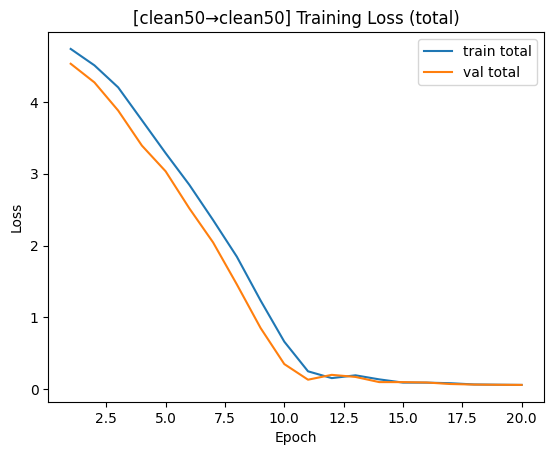

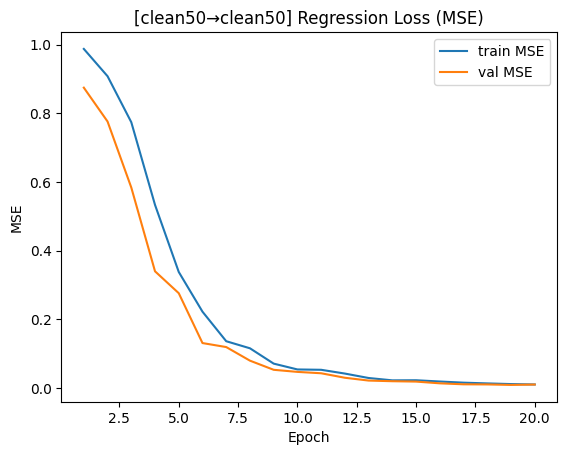

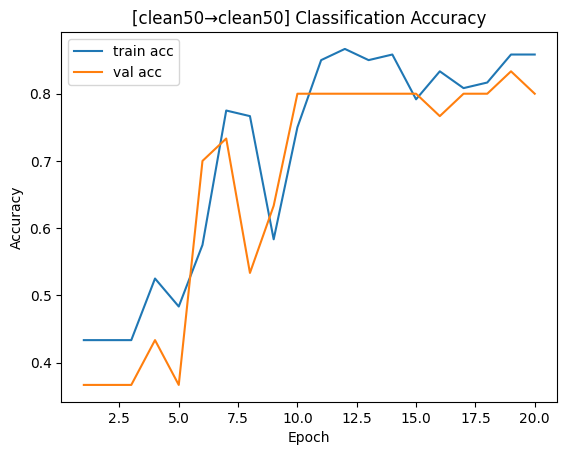

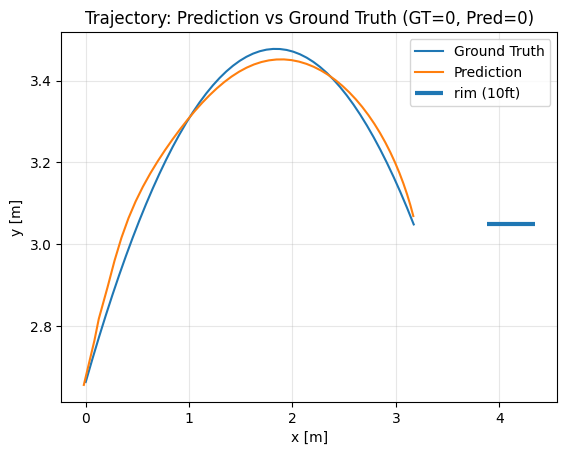

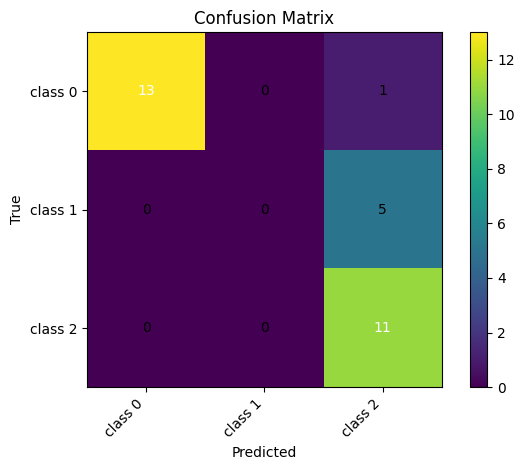

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dg = DataGen()

# --- Mode 1: clean50 -> clean50 ---
df_clean = dg.generate_dataset(n=150, n_points=50, with_noise=False)
df_clean_full = df_clean.copy()

tr_df, va_df = split_by_wurf_id(df_clean_full, test_size=0.2, seed=42)

scaler = XYScaler()
train_ds = TrajectoryCompletionDataset(
    tr_df, mode="clean", seq_len=50, scaler=scaler, fit_scaler=True
)
val_ds = TrajectoryCompletionDataset(
    va_df, mode="clean", seq_len=50, scaler=scaler, fit_scaler=False
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

model_full_clean = SeqRegClsModel(input_dim=4, hidden_dim=128, num_layers=2)
model_full_clean, hist = train_full_seq(
    model_full_clean, train_loader, val_loader, device=device, epochs=20, lr=1e-3, cls_weight=0.1
)

plot_training_history(hist, title_prefix="[clean50→clean50] ")
plot_pred_vs_gt_trajectory(
    model_full_clean,
    val_loader,
    scaler=train_ds.scaler,
    device=device,
    sample_idx_in_batch=0,
)
plot_confusion_matrix(model_full_clean, val_loader, device=device, class_names=None)


## Noisy‑Training → Wurfklassifikation

[Full] ep=01 train=4.3316 val=4.1185 acc=0.533 ic=3.0545
[Full] ep=05 train=2.8945 val=2.6244 acc=0.533 ic=2.2564
[Full] ep=10 train=0.6391 val=0.4090 acc=0.767 ic=0.1802
[Full] ep=15 train=0.1208 val=0.1372 acc=0.867 ic=0.0167
[Full] ep=20 train=0.0814 val=0.0908 acc=0.867 ic=0.0048


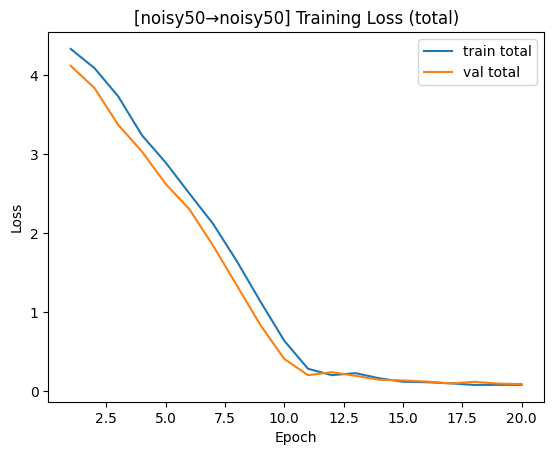

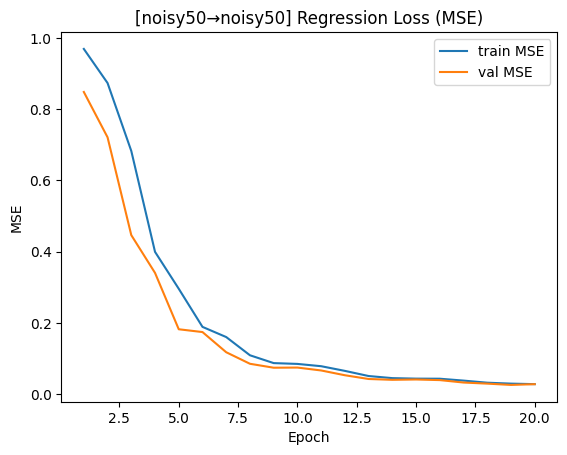

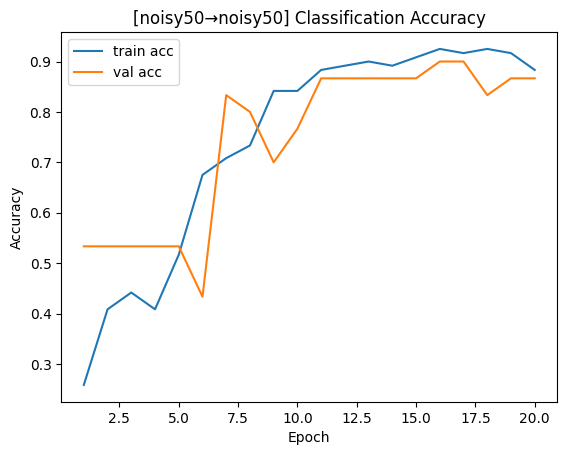

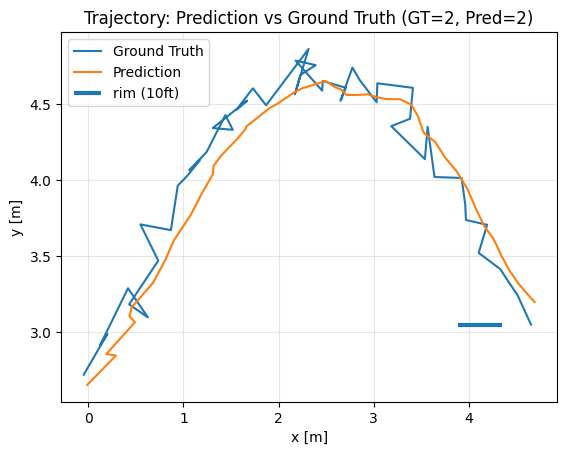

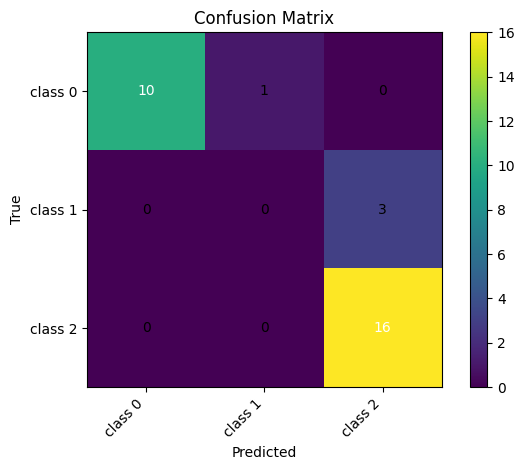

In [9]:
# --- Mode 2: noisy50 -> noisy50 (explicitly as requested) ---
df_noisy = dg.generate_dataset(n=150, n_points=50, with_noise=True, noise_std=0.1)
df_noisy_full = df_noisy.copy()

tr_df_n, va_df_n = split_by_wurf_id(df_noisy_full, test_size=0.2, seed=42)

scaler = XYScaler()
train_ds_n = TrajectoryCompletionDataset(
    tr_df_n, mode="noisy", seq_len=50, scaler=scaler, fit_scaler=True
)
val_ds_n = TrajectoryCompletionDataset(
    va_df_n, mode="noisy", seq_len=50, scaler=scaler, fit_scaler=False
)

train_loader_n = DataLoader(train_ds_n, batch_size=32, shuffle=True)
val_loader_n = DataLoader(val_ds_n, batch_size=64, shuffle=False)

model_full_noisy = SeqRegClsModel(input_dim=4, hidden_dim=128, num_layers=2)
model_full_noisy, hist_n = train_full_seq(
    model_full_noisy, train_loader_n, val_loader_n, device=device, epochs=20
)

plot_training_history(hist_n, title_prefix="[noisy50→noisy50] ")
plot_pred_vs_gt_trajectory(
    model_full_noisy,
    val_loader_n,
    scaler=train_ds_n.scaler,
    device=device,
    sample_idx_in_batch=0,
)
plot_confusion_matrix(model_full_noisy, val_loader_n, device=device, class_names=None)


## Trimmed‑Training → Sequence‑Completion / Extrapolation (30→50)


[Full] ep=01 train=4.7825 val=4.6383 acc=0.700 ic=3.4956
[Full] ep=05 train=3.4545 val=3.1601 acc=0.500 ic=2.6301
[Full] ep=10 train=0.8395 val=0.4971 acc=0.833 ic=0.2556
[Full] ep=15 train=0.2106 val=0.1677 acc=0.900 ic=0.0121
[Full] ep=20 train=0.1269 val=0.0749 acc=0.967 ic=0.0004
[Full] ep=25 train=0.0968 val=0.0563 acc=0.967 ic=0.0002
[Full] ep=30 train=0.0808 val=0.0420 acc=0.967 ic=0.0000


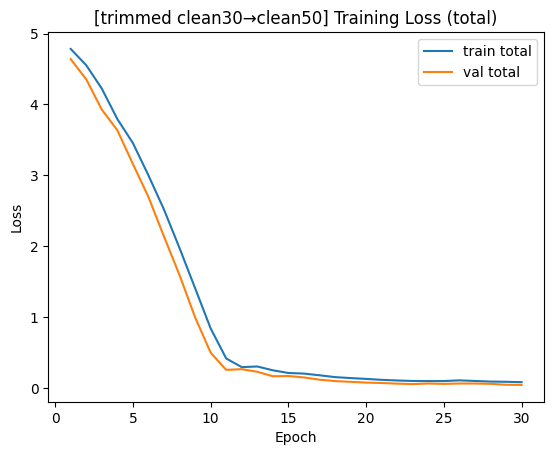

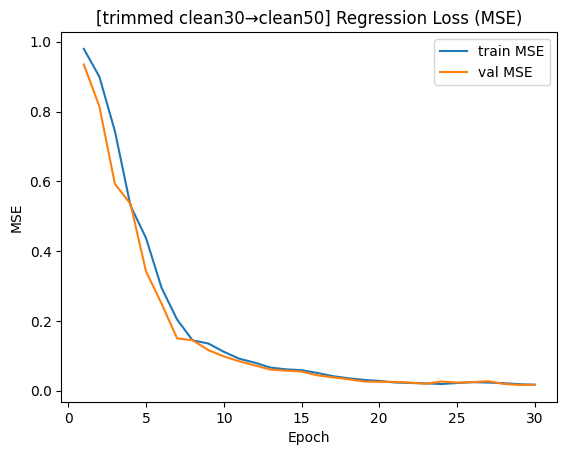

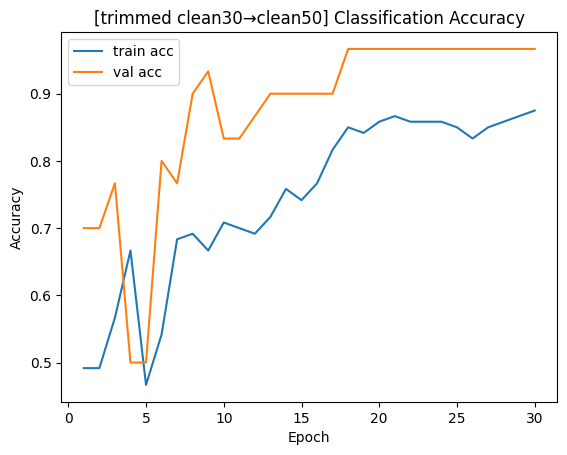

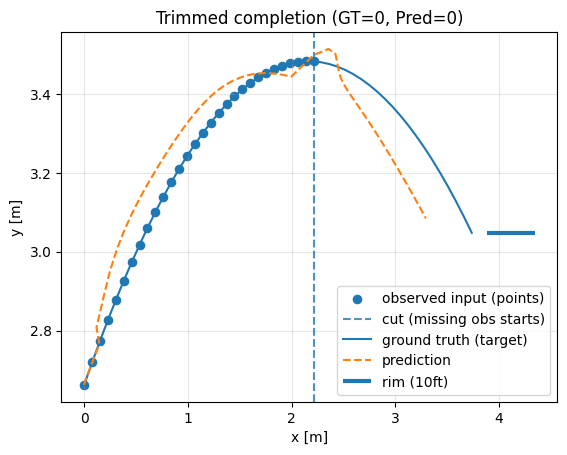

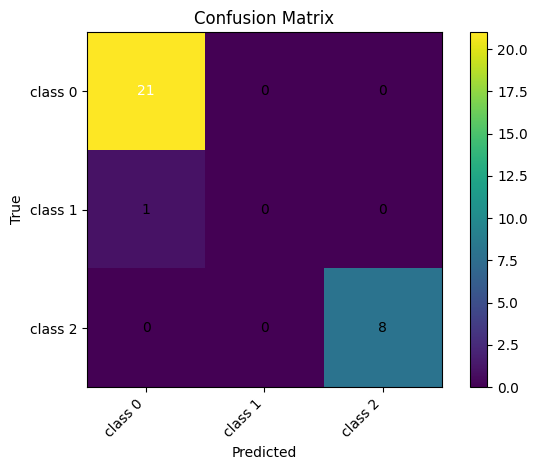

[Full] ep=01 train=4.8199 val=4.6840 acc=0.900 ic=3.5257
[Full] ep=05 train=3.4493 val=3.1658 acc=0.600 ic=2.6297
[Full] ep=10 train=0.7670 val=0.4241 acc=0.833 ic=0.1958
[Full] ep=15 train=0.2220 val=0.1762 acc=0.867 ic=0.0083
[Full] ep=20 train=0.1618 val=0.1141 acc=0.900 ic=0.0023
[Full] ep=25 train=0.1034 val=0.0619 acc=0.967 ic=0.0001
[Full] ep=30 train=0.0848 val=0.0514 acc=0.933 ic=0.0003


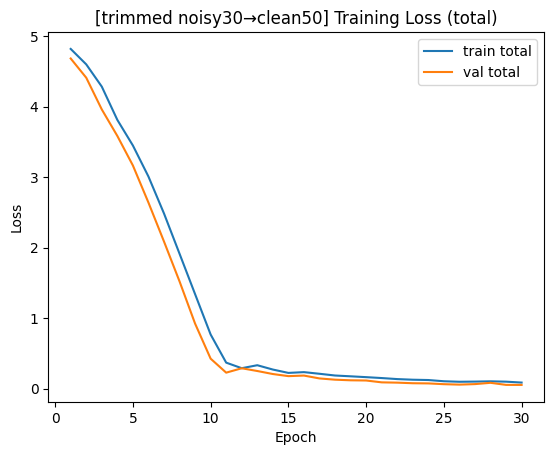

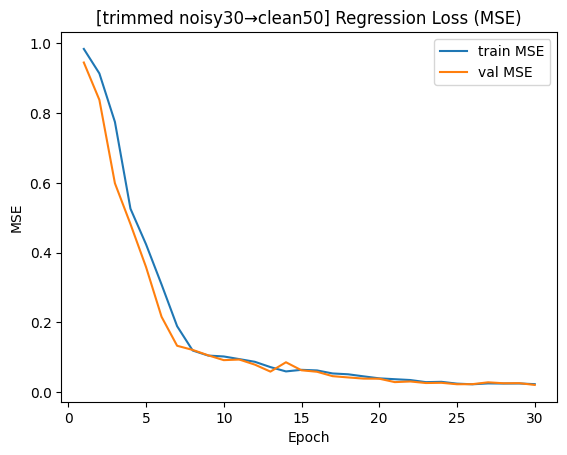

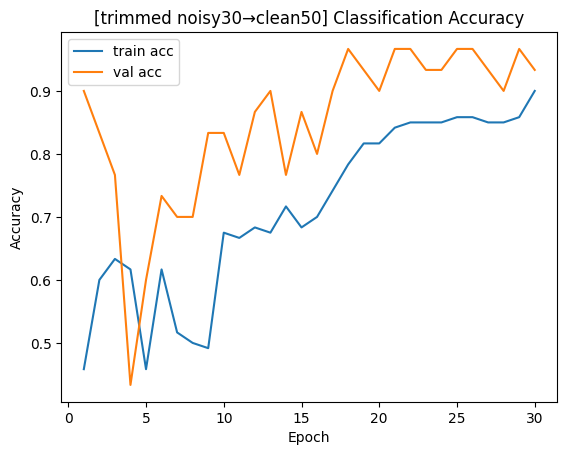

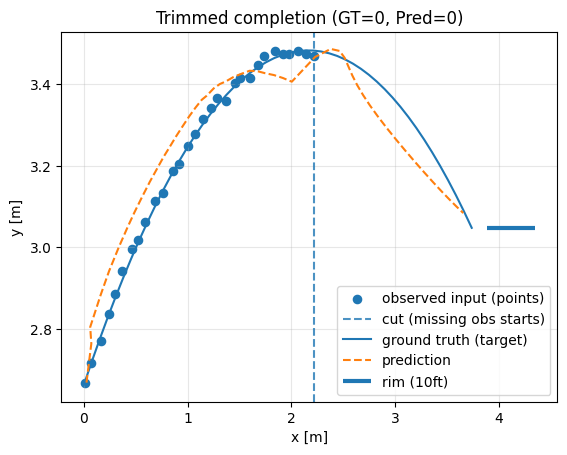

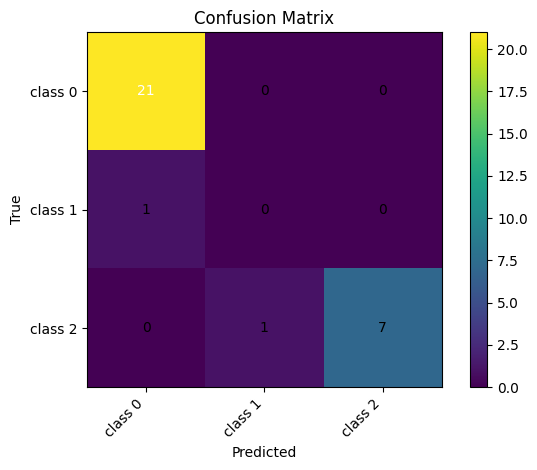

In [10]:
# --- Mode 3: trimmed (clean/noisy)30 -> clean50 ---
# We generate a dataset that contains BOTH clean and noisy columns.
df_both = dg.generate_dataset(n=150, n_points=50, with_noise=True, noise_std=0.01)
df_both_full = df_both.copy()

tr_df_t, va_df_t = split_by_wurf_id(df_both_full, test_size=0.2, seed=42)

# (A) trimmed: clean30 -> clean50
scaler_a = XYScaler()
train_ds_t_clean = TrajectoryCompletionDataset(
    tr_df_t,
    mode="trimmed",
    input_len=30,
    input_variant="clean",
    seq_len=50,
    scaler=scaler_a,
    fit_scaler=True,     # NOTE: fit on clean TARGET distribution
)
val_ds_t_clean = TrajectoryCompletionDataset(
    va_df_t,
    mode="trimmed",
    input_len=30,
    input_variant="clean",
    seq_len=50,
    scaler=scaler_a,
    fit_scaler=False,
)

train_loader_t_clean = DataLoader(train_ds_t_clean, batch_size=32, shuffle=True)
val_loader_t_clean = DataLoader(val_ds_t_clean, batch_size=64, shuffle=False)

model_trim_clean = SeqRegClsModel(input_dim=4, hidden_dim=128, num_layers=2)
model_trim_clean, hist_tc = train_full_seq(
    model_trim_clean, train_loader_t_clean, val_loader_t_clean, device=device, epochs=30
)

plot_training_history(hist_tc, title_prefix="[trimmed clean30→clean50] ")
plot_completion_with_mask(
    model_trim_clean,
    val_loader_t_clean,
    scaler=train_ds_t_clean.scaler,
    device=device,
    sample_idx_in_batch=0,
)
plot_confusion_matrix(model_trim_clean, val_loader_t_clean, device=device, class_names=None)


# (B) trimmed: noisy30 -> clean50
scaler_b = XYScaler()
train_ds_t_noisy = TrajectoryCompletionDataset(
    tr_df_t,
    mode="trimmed",
    input_len=30,
    input_variant="noisy",
    seq_len=50,
    scaler=scaler_b,
    fit_scaler=True,     # fit on clean TARGET distribution (same as above, separate instance)
)
val_ds_t_noisy = TrajectoryCompletionDataset(
    va_df_t,
    mode="trimmed",
    input_len=30,
    input_variant="noisy",
    seq_len=50,
    scaler=scaler_b,
    fit_scaler=False,
)

train_loader_t_noisy = DataLoader(train_ds_t_noisy, batch_size=32, shuffle=True)
val_loader_t_noisy = DataLoader(val_ds_t_noisy, batch_size=64, shuffle=False)

model_trim_noisy = SeqRegClsModel(input_dim=4, hidden_dim=128, num_layers=2)
model_trim_noisy, hist_tn = train_full_seq(
    model_trim_noisy, train_loader_t_noisy, val_loader_t_noisy, device=device, epochs=30
)

plot_training_history(hist_tn, title_prefix="[trimmed noisy30→clean50] ")
plot_completion_with_mask(
    model_trim_noisy,
    val_loader_t_noisy,
    scaler=train_ds_t_noisy.scaler,
    device=device,
    sample_idx_in_batch=0,
)
plot_confusion_matrix(model_trim_noisy, val_loader_t_noisy, device=device, class_names=None)